# Network Lasso and Localized Lasso
In this notebook, we code two network Lasso methods from:
* Network Lasso by Hallac et al 2015
* Localized Lasso by Yameda et al. 2017 . In this latter case, we modify the method to correspond to our problem of interest. 

Our problem is the followin, given a graph $G = (V,E)$, we try to solve:
$$\min_{W \in \mathbb{R}^{U \times d}} \frac{1}{2}\sum_{u= 1}^U \Vert X_u w_i^T - y_u\Vert + \frac{1}{2}\lambda \Vert W\Vert_F^2 + \alpha\sum_{(i,j)\in E}\Vert w_i - w_j\Vert_2$$
    
where $w_i$ is the $i-$th row of $W$, and $X_u$ is a design matrix per task

In [1]:
import utils
import numpy as np
random = np.random.default_rng()
from tqdm import tqdm
from matplotlib import pyplot as plt
from scipy.spatial.distance import pdist, squareform
import networkx as nx
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, SpectralEmbedding
from functools import partial
from scipy import sparse
from math import sqrt

## Network Lasso

We apply Algorithm 1 from Hallac et al. 2015

$${\bf repeat} \\
    \qquad  w_i^{k+1} =  \underset{w_i}{\mathrm{argmin}} \frac{1}{2}\left(\Vert X_u w_i^T - y_u\Vert^2 + \frac{1}{2}\lambda \Vert W\Vert_F^2 + \sum\limits_{j \in N(i)} (\rho/2)\|w_i - z_{ij}^k + u_{ij}^k\|_2^2\right) \\
     z_{ij}^{k+1} = \theta(w_i + u_{ij}) + (1-\theta)(w_j + u_{ji}) \\
     z_{ji}^{k+1} = (1-\theta)(w_i + u_{ij}) + \theta(w_j + u_{ji}) \\   
     u_{ij}^{k+1} = u_{ij}^{k} + (w_i^{k+1} - z_{ij}^{k+1}) \\
    {\bf until}  \|r^k\|_2 \leq \epsilon^{\mathrm{pri}}; \|s^k\|_2 \leq \epsilon^{\mathrm{dual}}$$
    

where $\theta = \max\left(1-\lambda\cfrac{a_{ij}}{\rho\Vert w_{i} + u_{ij} - (w_j + u_{ji})\Vert_2}, 0.5\right)$.


### "Naive" implementation
All edges, null  and non null are representeed

In [2]:
def transp(tensor):
    return np.transpose(tensor, (1,0,2))

# def jtransp(tensor):
#     return jnp.transpose(tensor, (1,0,2))

def extended_incidence(Adj):
    n_nodes = len(Adj)
    tri_inds = np.triu_indices(n_nodes)
    Adj_tri_vec = Adj[tri_inds]
    i_is_edge_source = (tri_inds[0] == np.arange(n_nodes)[:,None])
    edge_exists = Adj_tri_vec>0 
    return sparse.csr_array(edge_exists*i_is_edge_source).astype("float64")

def solve_network_lasso(Adj, first_term, l_net= 1.0, rho= 1.0, primal_thd= 1e-8, dual_thd= 1e-8, max_iter= 100):
    primal_gap = primal_thd + 1.0
    dual_gap = dual_thd + 1.0
    
    r_list = []
    s_list = []
    val_list= []
    dim = first_term.dim
    
    first_term.initialize(rho, Adj)

    u_tens = np.zeros((len(Adj), len(Adj), first_term.dim))
    z_tens = np.zeros((len(Adj), len(Adj), first_term.dim))
    mu = 10
    tau_inc = tau_dec = 2
    theta = np.ones_like(Adj)
    inds1, inds2 = np.where(Adj>0)
    for _ in tqdm(range(max_iter)):
        z_tens_old = z_tens.copy()

        # algorithm steps
        w_mat = first_term.prox(rho= rho, z_minus_u= z_tens_old - u_tens)
        w_tens = w_mat[:,None,:]#np.einsum('ik,jk->ijk', w_mat, ones)
        in_denom = w_tens - transp(w_tens) + u_tens - transp(u_tens)
        theta = np.maximum(0.5, 1-l_net/rho*Adj/(np.linalg.norm(in_denom, axis= -1, ord= 2) + 1e-10))
        theta = theta[:,:,None]
        w_u_tens = w_tens + u_tens
        z_tens = theta * w_u_tens + (1-theta) * transp(w_u_tens)
        u_tens  += w_tens - z_tens
        
        if np.any(z_tens>1e100) or np.any(u_tens>1e100):
                print("V!",end='')
        # stopping 
        primal_gap = np.max(np.linalg.norm(w_tens - z_tens, axis= 2, ord= 2))
        dual_gap = rho*np.max(np.linalg.norm(z_tens_old - z_tens, axis= 2))
        # Updating rho
        if primal_gap>mu*dual_gap: rho *= tau_inc
        if dual_gap>mu*primal_gap: rho /= tau_dec

        r_list.append(primal_gap)
        s_list.append(dual_gap)

        if np.any(np.isnan(z_tens)) or np.any(np.isnan(u_tens)):
            print("!", end= "")
        if primal_gap <= primal_thd and dual_gap <= dual_thd:
            break
        
    return w_mat, np.array(r_list), np.array(s_list)

def transp_vec_inds(v, indices, n_nodes):
    a = np.zeros(n_nodes**2)
    a[indices] = v
    A_transp = a.reshape((n_nodes, n_nodes)).T.flatten()
    return A_transp[A_transp>0] 

### Efficient implementation
Only existing edges are represented. This not only has the advantage to reduce memory usage for sparse graphs, but also allows 

In [3]:
def solve_network_lasso_eff(Adj, first_term, l_net= 1.0, rho= 1.0, primal_thd= 1e-8, dual_thd= 1e-8, max_iter= 100,
                            eps_abs = 1e-6, eps_rel = 1e-3):
    primal_gap = primal_thd + 1.0
    dual_gap = dual_thd + 1.0
    
    r_list = []
    s_list = []
    val_list= []
    dim = first_term.dim
    
    Adj_bool = Adj>0
    first_term.initialize(rho, Adj_bool)
    
    weights = Adj[Adj_bool]
    n_edges_2 = np.sum(Adj_bool)
    u = np.zeros((n_edges_2, first_term.dim))
    z = np.zeros((n_edges_2, first_term.dim))
    

    # rho adaptivituy
    mu = 10
    tau_inc = tau_dec = 2
    
    
    # prepare indices of transposition operation
    inds = np.where(Adj_bool.flatten())[0] # indices of non null weights
    n_nodes = len(Adj)
    support = -np.ones(n_nodes**2, dtype= "int64")
    support[inds] = np.arange(n_edges_2) # inject the range 0 : n_edges into the n_nodes**2 array
    range_n_2 = np.arange(n_nodes**2) # range of n_nodes **2 array
    # FIXME support_permut seems to have a length smaller than inds
    support_permut = support[n_nodes*(range_n_2%n_nodes)+range_n_2//n_nodes] #transpose the support array, as if its corresponding matrix is transposed
    range_transp = support_permut[support_permut>=0] # get the corresponding transposed range of edges

    range_nodes = np.arange(n_nodes)
    nodes_to_edges_2  = sparse.csr_array((range_nodes[:,None] ==  np.repeat(range_nodes, Adj_bool.sum(axis=1))).astype("float64"))
    
    # For stopping thresholds
    eps_abs_primal = sqrt(n_edges_2*dim)*eps_abs
    eps_abs_dual = sqrt(n_nodes*dim)*eps_abs
    for _ in tqdm(range(max_iter)):
        z_old = z.copy()

        # algorithm steps
        w_mat = first_term.prox_sparse(rho= rho, z_minus_u= z_old - u)
        w_rep = np.repeat(w_mat, repeats= Adj_bool.sum(axis= 1), axis= 0)#np.einsum('ik,jk->ijk', w_mat, ones)
        in_denom = w_rep - w_rep[range_transp] + u - u[range_transp]
        theta = np.maximum(0.5, 1-l_net/rho*weights/(np.linalg.norm(in_denom, axis= 1, ord= 2) + 1e-8))
        theta = theta[:,None]
        w_u = w_rep + u
        z = theta * w_u + (1-theta) * w_u[range_transp]
        u  += w_rep - z
        
        if np.any(z>1e100) or np.any(u>1e100):
                print("V!",end='')
        # stopping 
        primal_thd = eps_abs_primal + eps_rel * max(np.linalg.norm(w_rep, ord= "fro"), np.linalg.norm(z, ord= "fro"))
        dual_thd = eps_abs_dual + eps_rel * np.linalg.norm(nodes_to_edges_2.dot(u), ord= "fro")
        primal_gap = np.max(np.linalg.norm(w_rep - z, axis= 1, ord= 2))
        dual_gap = rho*np.max(np.linalg.norm(nodes_to_edges_2.dot(z_old - z), axis= 1))
        # Updating rho
        # if primal_gap>mu*dual_gap: rho *= tau_inc
        # if dual_gap>mu*primal_gap: rho /= tau_dec

        r_list.append(primal_gap)
        s_list.append(dual_gap)
        if np.any(np.isnan(z)) or np.any(np.isnan(u)):
            print("!", end= "")
        if primal_gap <= primal_thd and dual_gap <= dual_thd:
            break
        
    return w_mat, np.array(r_list), np.array(s_list)

### Constructing true vector

In [8]:
dim = 2
n_nodes = 20
#Adj = utils.graph_Erdos_Renyi(n_vertices= n_nodes, p= 0.4)
W_true_raw = random.standard_normal((n_nodes, dim))

Adj, W_true_raw = utils.graph_rbf(node_num= n_nodes, dimension= dim, sparsity= 1.0, clusters= 10)

l_net = 1.0
l_reg = 1.0

class L2():
    def __init__(self, W_raw):
        self.W_raw = W_raw
        self.dim = W_raw.shape[1]
    
    def initialize(self, rho, Adj):
        self.Adj_bin = (Adj>0).astype("int64")
        self.denom = 1 + rho*self.Adj_bin.sum(axis=1)
        range_nodes = np.arange(len(Adj))
        self.nodes_to_edges_2  = sparse.csr_array((range_nodes[:,None] ==  np.repeat(range_nodes, self.Adj_bin.sum(axis=1))).astype("float64"))
        return self
    
    def prox(self, rho, z_minus_u):
        return (self.W_raw + rho*np.einsum('ij, ijk -> ik', self.Adj_bin, z_minus_u)) /self.denom[:,None]
    
    def prox_sparse(self, rho, z_minus_u):
        return (self.W_raw + rho*self.nodes_to_edges_2.dot(z_minus_u)) /self.denom[:,None]

L2_term = L2(W_raw= W_true_raw)

# W_true, r_list, s_list = solve_network_lasso(Adj, L2_term, rho= 1.0, l_net= 1.0, max_iter= 100)
W_true, r_list, s_list = solve_network_lasso_eff(Adj, L2_term, rho= 1, l_net= 1, max_iter= 100)
#W_true /= np.linalg.norm(W_true, axis= 1, ord= 2)

 73%|███████▎  | 73/100 [00:00<00:00, 3936.59it/s]


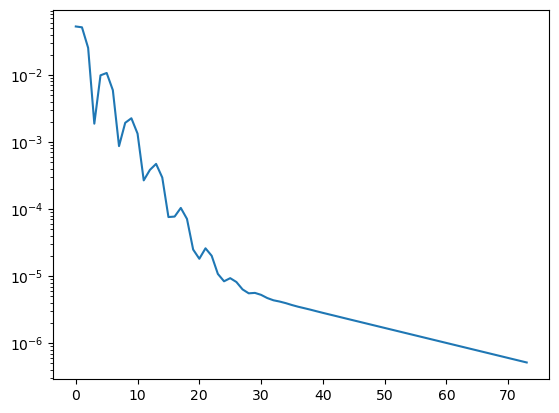

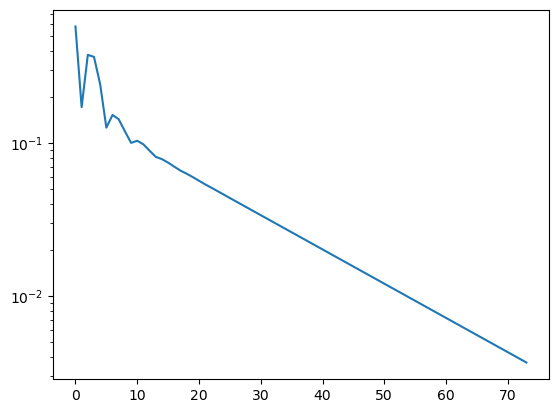

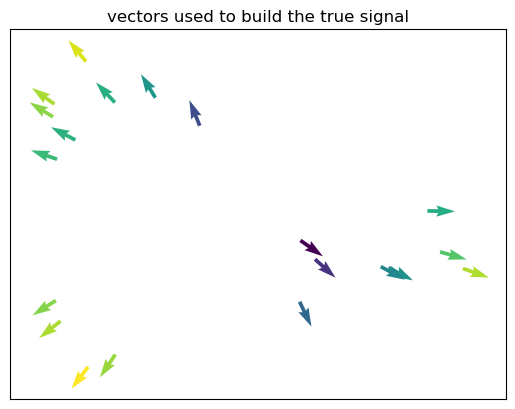

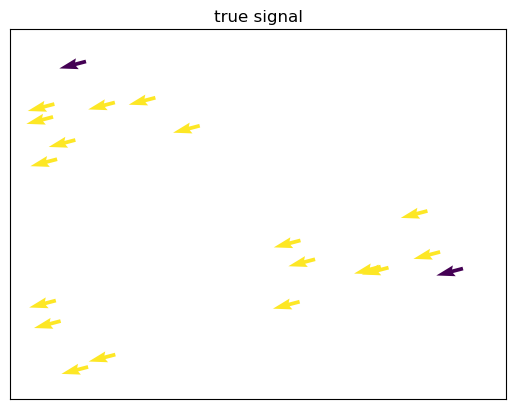

In [9]:
plt.figure()
plt.semilogy(r_list)

plt.figure()
plt.semilogy(s_list)

graph = nx.from_numpy_array(Adj)
if dim>2:
    embedding = PCA(n_components= 2)
    # embedding = TSNE(perplexity= 10, init= 'pca', n_iter= 2000)
    # embedding = SpectralEmbedding(n_components= 2, affinity= 'rbf', gamma= 0.01)
    W_true_embedded = embedding.fit_transform(W_true)

if dim == 2:
    pos = W_true_raw
    plt.figure()
    utils.quiver_graph(graph= graph, pos= W_true_raw, signal= W_true_raw, alpha= 0.0)
    plt.title("vectors used to build the true signal")


    plt.figure()
    utils.quiver_graph(graph= graph, pos= W_true_raw, signal= W_true, alpha= 0.0)
    plt.title("true signal")



### Solving regularized least squares

In [10]:
n_per_node = 50
X = random.standard_normal((n_nodes, n_per_node, dim))
X /= np.linalg.norm(X, axis= 2, ord= 2)[:,:,None]
y = np.einsum('kij, kj->ki', X, W_true) + 0.0*random.standard_normal((n_nodes, n_per_node))

class Lstsq():
    
    def __init__(self, X, y, l_reg= 1.0):
        self.b = np.einsum('ijk, ij -> ik', X, y)
        self.dim = self.b.shape[1]
        self.l_reg = l_reg
    
    def initialize(self, rho, Adj):
        self.Adj_bin = (Adj>0).astype("int64")
        V = np.einsum("ijk, ijl->ikl", X, X) + self.l_reg * np.tile(np.eye(self.dim), (len(Adj), 1 ,1))\
                                        + rho * np.einsum("i,jk->ijk", Adj.sum(axis=1), np.eye(self.dim))
        self. invV = np.linalg.inv(V)
        range_nodes = np.arange(len(Adj))
        self.nodes_to_edges_2  = sparse.csr_array((range_nodes[:,None] ==  np.repeat(range_nodes, self.Adj_bin.sum(axis=1))).astype("float64"))
        # self.nodes_to_edges_2  = (range_nodes[:,None] ==  np.repeat(range_nodes, self.Adj_bin.sum(axis=1))).astype("float64")        
        return self
        
    def prox(self, rho, z_minus_u):
        b_ext = self.b + rho*np.einsum('ij, ijk -> ik', self.Adj_bin, z_minus_u)
        return np.einsum('kij, kj -> ki', self.invV, b_ext)
    
    def prox_sparse(self, rho, z_minus_u):
        b_ext = self.b + rho* self.nodes_to_edges_2.dot(z_minus_u)
        return np.einsum('kij, kj -> ki', self.invV, b_ext)

# class Lstsq_jax():
    
#     def __init__(self, X, y, l_reg= 1.0):
#         self.b = jnp.einsum('ijk, ij -> ik', X, y)
#         self.dim = self.b.shape[1]
#         self.l_reg = l_reg
    
#     @partial(jit, static_argnums=0)
#     def initialize(self, rho, Adj):
#         V = jnp.einsum("ijk, ijl->ikl", X, X) + self.l_reg * jnp.tile(np.eye(self.dim), (len(Adj), 1 ,1))\
#                                         + rho * jnp.einsum("i,jk->ijk", Adj.sum(axis=1), np.eye(self.dim))
#         self. invV = jnp.linalg.inv(V)
#         return self
    
#     @partial(jit, static_argnums=0)   
#     def prox(self, rho, Adj, z_minus_u):
#         b_ext = self.b + rho*jnp.einsum('ij, ijk -> ik', Adj, z_minus_u)
#         return jnp.einsum('kij, kj -> ki', self.invV, b_ext)



 27%|██▋       | 27/100 [00:00<00:00, 3004.99it/s]


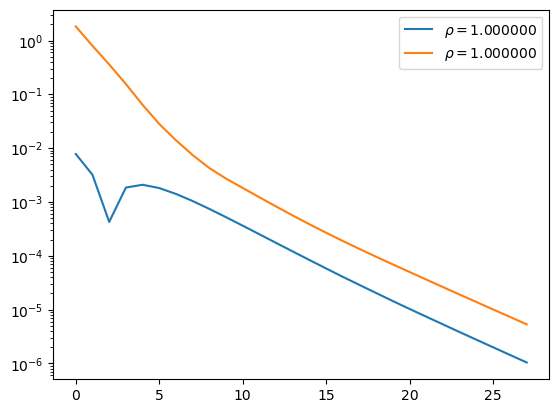

In [11]:
plt.figure()
for rho in [1.0]:
    lstsq_term = Lstsq(X, y, l_reg= 0.01)
    #W, r_list, s_list = solve_network_lasso(Adj, lstsq_term, rho= 1.0, l_net= 1e8, max_iter= 100)
    W, r_list, s_list = solve_network_lasso_eff(Adj, lstsq_term, rho= rho, l_net= 1e8, max_iter= 100)
    # lstsq_term = Lstsq_jax(X, y, l_reg= l_reg)
    # solve_network_lasso_lstq = jit(partial(solve_network_lasso_jax, first_term= lstsq_term))
    #W, r_list, s_list = solve_network_lasso_jax(Adj, lstsq_term, rho= rho, l_net= l_net, max_iter= 1000)
    # W, r_list, s_list = solve_network_lasso_lstq(Adj, rho= rho, l_net= l_net, max_iter= 1000)
    plt.semilogy(r_list, label= r"$\rho= %f$"%(rho))
    plt.semilogy(s_list, label= r"$\rho= %f$"%(rho))

plt.legend()

# plt.figure()
# plt.semilogy(s_list)



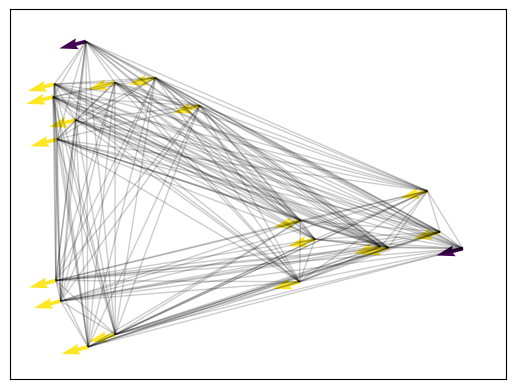

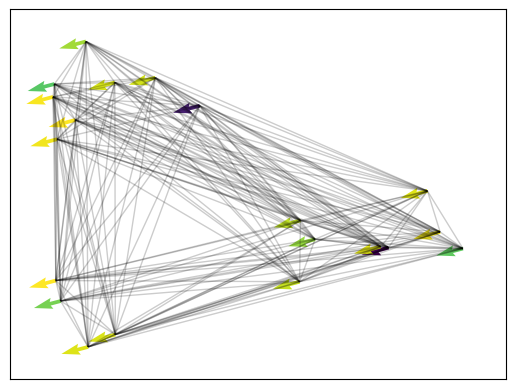

In [12]:
plt.figure()
utils.quiver_graph(graph, pos, W_true)

plt.figure()
utils.quiver_graph(graph, pos, W)

## Localized Lasso

In [13]:
# TODO

## Testing SnapVX
As in the paper of Hallac et al. 2015, we use the SnapVX library that is based on CVXPY and Snap for graphs. Howerver, since it is for python 2.7, we perform the following replacements to its main python file:
* `print '11'` ---> `print('11'`)
* `print "11"` ---> `print("11"`)
* `xange` ---> `range`
* Remove import `__builtin__` and all of the `__builtin__.` calls
* `size[` ---> `shape[`
* `iteritems` --> `items`
For printing statements, beware of the use of `%` for formatting !

Another point is whether it is better to use a python 2 to 3 converter directly.

In [14]:
# Helper function to define edge objectives
# Takes in two nodes, returns a problem defined with the variables from those nodes
# def laplace_reg(src, dst, data):
#   return (svx.sum_squares(src['x'] - dst['x']), [])

# # Generate random graph, using SNAP syntax
# np.random.seed(1)
# num_nodes = 10
# num_edges = 30
# n = 10
# snapGraph = svx.GenRndGnm(svx.PUNGraph, num_nodes, num_edges)
# gvx = svx.TGraphVX(snapGraph)

# # For each node, add an objective (using random data)
# for i in range(num_nodes):
#   x = svx.Variable(n,name='x') # Each node has its own variable named 'x'
#   a = np.random.randn(n)
#   gvx.SetNodeObjective(i, svx.square(svx.norm(x-a)))

# # Set all edge objectives at once (Laplacian Regularization)
# gvx.AddEdgeObjectives(laplace_reg)

# # Solve in verbose mode (using ADMM)
# gvx.Solve(Verbose=False,  NumProcessors=0)
# gvx.PrintSolution()

# #gvx.Solve(UseADMM=False) # Solve serially (no ADMM)
# #gvx.PrintSolution()

# # Print only the solution for 'x' at Node 1
# print("Solution at Node 1 is"), gvx.GetNodeValue(1,'x')

In [15]:
def extended_incidence(Adj):
    tri_inds = np.triu_indices(len(Adj))
    Adj_tri_vec = Adj[tri_inds]
    print(Adj_tri_vec)
    return (Adj_tri_vec>0)*(tri_inds[0] == np.arange(n_nodes)[:,None])

### Test of vectorization
The goal is to leverage sparisity. Alas, there is no support for sparsity for tensors of order higher than 2. 
* Vectorization of "ij, ijk-> ik" into an operation between a vectorized incidence matrix and a variable of shape $(|V|^2, d)$
* vectorization of the transposition switching axes 0 and 1 operations over tensors of size $(|V|^2, d)$

In [16]:
Adj_bin = (Adj>0).astype("float64")
T = random.random((n_nodes, n_nodes, dim))
operation_tensor = np.einsum("ij, ijk -> ik", Adj_bin, T)
T_vec = T.reshape((n_nodes**2, dim))
Adj_vec = Adj_bin.flatten()
equiv_operator = np.kron(np.eye(n_nodes), np.ones(n_nodes))*Adj_vec
equiv_operator_bool = equiv_operator.astype("bool")
operation_vec = equiv_operator @ T_vec
assert np.all(np.isclose(operation_vec,  operation_tensor))


In [17]:
from scipy import sparse
equiv_op_sparse = sparse.coo_array(equiv_operator)
equiv_operator_sparse = sparse.linalg.aslinearoperator(equiv_operator)

%timeit np.einsum("ij, ijk -> ik", Adj_bin, T)
%timeit equiv_operator @ T_vec
%timeit equiv_op_sparse.dot(T_vec)
%timeit equiv_operator_sparse(T_vec)



4.85 µs ± 752 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
4.78 µs ± 532 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
8.41 µs ± 270 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
5.86 µs ± 63.9 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


### Test tranpose of a vectorized matrix

In [20]:
n = 100
M = random.random((n,n))
M_vec = M.flatten()
n_range = np.arange(n**2)
M_transp_vec = M_vec[n*(n_range%n)+n_range//n]
np.all(M_transp_vec == M.T.flatten())


True

In [19]:
np.bincount([1,1,2,2], [[0.5,0.2,0.2,0.3], [0.5,0.2,0.2,0.3]])

ValueError: object too deep for desired array

In [ ]:
v = random.random(1000)
print(np.maximum(v, 0.5) - np.clip(v, 0.5, None))
%timeit (np.abs(v-0.5) + v + 0.5)/2
%timeit np.maximum(v, 0.5)
%timeit np.clip(v, 0.5, None)


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [110]:
G = nx.Graph(Adj)
B = nx.incidence_matrix(G, oriented= True).T # oriented to have positive and negative values
weights = np.sqrt(Adj[*np.array(G.edges).T]) # weights of A sorted according to edges, sqrt is taken because the Laplacian is a quadratic function, but in our project we do not take it
B.data *= np.repeat(weights, repeats= 2) # inject weights into incidence matrix

# Test whether the incidence matrix and the Laplacian are compatible
L_B = B.T@B # Laplacian obtained from the incidence
L_B = L_B.todense()
L = nx.laplacian_matrix(G).todense()
print(np.all(np.isclose(L, L_B)))
print(np.max(np.abs(L - L_B))) # maximum absolute difference


True
3.552713678800501e-15


In [104]:
len(np.repeat(np.sqrt(Adj[*np.array(G.edges).T]), repeats= 2))

378

In [116]:
B = nx.incidence_matrix(G, oriented= True, weight= "weight").T # oriented to have positive and negative values


In [120]:
B["weight"]

IndexError: Index dimension must be 1 or 2